# Optimalizace tras rozvozu na poslední míli pomocí PROC OPTMODEL (síťový TSP)


## Shrnutí pro vedení

Regionální logistický přepravce potřebuje naplánovat trasu jednoho rozvozového
vozidla přes sadu zákaznických zastávek a vrátit se do depa s minimální celkovou
ujetou vzdáleností — jde o strukturu úlohy obchodního cestujícího (TSP), která
je základem denního plánování tras a směn. Tento notebook vygeneruje souřadnice
zastávek, sestaví symetrickou euklidovskou matici vzdáleností a použije síťový
řešič **PROC OPTMODEL** `SOLVE WITH NETWORK / TSP` k sestavení rozvozové trasy
přes úplný graf zastávek. Poté načte pořadí trasy vrácené řešičem zpět do DATA
kroku, sestaví uzavřenou trasu ukotvenou v depu a změří její **skutečnou**
celkovou délku z matice vzdáleností. Každé níže uvedené číslo je vypočteno
z reálného výstupu spuštěného programu.


## Zdroje dat

Všechna data jsou generována přímo v programu pomocí `call streaminit(...)` a
`rand(...)` — bez externích souborů nebo síťového přístupu.

| Dataset | Řádky | Klíčové proměnné | Popis |
|---------|------|---------------|-------------|
| `stops` | 12 (1 depo + 11 zákazníků) | `stop_id`, `name`, `x`, `y` | Syntetické 2D souřadnice (km na mřížce obslužné oblasti) pro depo a zákaznické rozvozové lokality |
| `tour` | 12 | `visit_order`, `node` | Seřazený seznam zastávek navštívených síťovým TSP řešičem OPTMODEL, zapsaný pomocí `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | Uzavřená trasa ukotvená v depu s vzdálenostmi jednotlivých úseků a kumulativní vzdáleností vypočtenou ze souřadnic |


Přepravce pro poslední míli vypravuje každé ráno jeden dodávkový vůz, aby
rozvezl zboží k pevné sadě zákaznických zastávek a vrátil se do depa. Dispečer
chce krátkou uzavřenou trasu, která navštíví každou zastávku právě jednou —
jde o úlohu obchodního cestujícího (TSP), jádro denního plánování tras a směn.

SAS/OR zpřístupňuje TSP řešič přes **`PROC OPTMODEL`**: deklarujte uzly a
ohodnocenou množinu hran, poté zavolejte `SOLVE WITH NETWORK / TSP`. Tento
notebook:

1. Vygeneruje souřadnice zastávek a symetrickou matici vzdáleností.
2. Zavolá síťový TSP řešič OPTMODEL nad úplným grafem zastávek.
3. Načte trasu vrácenou řešičem a sestaví z ní uzavřenou trasu ukotvenou v depu.
4. Vypíše trasu a její naměřenou celkovou délku, úsek po úseku.


## Krok 1 — Vygenerování rozvozové sítě

Umístíme depo do středu obslužné oblasti o rozměru 100 km x 100 km a rozmístíme
11 zákaznických zastávek rovnoměrně po mřížce. Souřadnice jsou generovány pomocí
`rand('UNIFORM')` s pevným počátečním bodem `streaminit`, takže síť je
reprodukovatelná. Depo má `stop_id = 1`; trasa v něm začne i skončí.


In [1]:
data stops;
    CALL streaminit(20260531);
    DÉLKA name $20;
    n_stops = 12;                 /* 1 depo + 11 zákazníků */
    OPAKUJ stop_id = 1 TO n_stops;
        KDYŽ stop_id = 1 PAK OPAKUJ;
            name = 'Depo';
            x = 50; y = 50;       /* depo ukotveno ve středu mřížky */
        KONEC;
        JINAK OPAKUJ;
            name = cats('Zastávka_', ZAPSAT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        KONEC;
        VÝSTUP;
    KONEC;
    ODSTRANIT n_stops;
SPUSTIT;

PROCEDURA TISK data=stops noobs ŠTÍTEK;
    ŠTÍTEK stop_id = 'Zastávka č.' name = 'Umístění' x = 'X (km)' y = 'Y (km)';
    NÁZEV 'Rozvozová síť: depo a zákaznické zastávky';
SPUSTIT;


                                       Rozvozová síť: depo a zákaznické zastávky                                        

    Umístění    Zastávka č.  X (km)  Y (km)
Depo                      1      50      50
Zastávka_01               2    84.2    89.7
Zastávka_02               3    93.1    73.6
Zastávka_03               4    21.2      29
Zastávka_04               5    49.4    73.4
Zastávka_05               6    97.8    37.2
Zastávka_06               7      28    51.3
Zastávka_07               8    91.1    86.5
Zastávka_08               9    89.2    65.6
Zastávka_09              10      66    49.4
Zastávka_10              11    52.2    27.4
Zastávka_11              12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Krok 2 — Vyřešení TSP pomocí PROC OPTMODEL

Načteme souřadnice do OPTMODEL, deklarujeme úplnou neorientovanou množinu hran
`EDGES` (každou neuspořádanou dvojici zastávek) a definujeme váhu každé hrany
jako euklidovskou vzdálenost mezi jejími koncovými body. `SOLVE WITH NETWORK /
TSP` poté sestaví trasu nad tímto grafem a zapíše pořadí návštěv do CSV souboru
pomocí `OUT=(TOUR=...)`. Toto pořadí ihned načteme zpět do datasetu `tour`.


In [2]:
PROCEDURA optmodel;
    NASTAVIT CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Načtení souřadnic zastávek z DATA kroku */
    READ data stops INTO [stop_id] XC=x YC=y;

    /* Úplný graf: jedna neorientovaná hrana pro každou neuspořádanou dvojici zastávek */
    NASTAVIT EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Váha hrany = přímá (euklidovská) vzdálenost, v km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Síťový TSP řešič: navštívit každý uzel a vrátit se na start */
    solve WITH network /
        links = (include=EDGES VÁHA=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Načtení pořadí návštěv vráceného řešičem zpět do datasetu */
data tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    VSTUP visit_order node;
SPUSTIT;

PROCEDURA TISK data=tour noobs ŠTÍTEK;
    ŠTÍTEK visit_order = 'Návštěva č.' node = 'Zastávka č.';
    NÁZEV 'Pořadí trasy vrácené síťovým TSP řešičem OPTMODEL';
SPUSTIT;


                                       Rozvozová síť: depo a zákaznické zastávky                                        


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                                   Pořadí trasy vrácené síťovým TSP řešičem OPTMODEL                                    

    Návštěva č.    Zastávka č.
              1              1
              2              7
              3              4
              4             11
              5             12
              6           


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Krok 3 — Sestavení uzavřené trasy a měření její délky

Řešič vrací pouze *pořadí*, v jakém navštívit zastávky. Abychom z něj sestavili
manifest pro řidiče, vyhledáme název a souřadnice každé zastávky pomocí
vyhledávání `SET ... POINT=`, sečteme délku každého úseku a uzavřeme smyčku
přidáním posledního úseku zpět do depa. `leg_km` je délka úseku, který
*přichází* na danou zastávku; `cum_km` je průběžná vzdálenost od depa.


In [3]:
data route;
    NASTAVIT tour KONEC=last;
    /* Vyhledání souřadnic a názvu této zastávky podle jejího id */
    ptr = node;
    NASTAVIT stops point=ptr;

    DÉLKA step_name $20;
    step_name = name;

    UCHOVAT prevx prevy firstx firsty cum_km;
    KDYŽ _n_ = 1 PAK OPAKUJ;
        firstx = x; firsty = y;      /* zapamatování depa */
        leg_km = 0;                  /* na start nepřichází žádný úsek */
        cum_km = 0;
    KONEC;
    JINAK OPAKUJ;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    KONEC;
    prevx = x; prevy = y;
    VÝSTUP;

    KDYŽ last PAK OPAKUJ;
        /* Uzavírací úsek: poslední zastávka zpět do depa */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Depo';
        x = firstx; y = firsty;
        VÝSTUP;
        CALL symputx('total_km', ZAPSAT(cum_km, 8.2));
    KONEC;
    PONECHAT visit_order node step_name x y leg_km cum_km;
SPUSTIT;

PROCEDURA TISK data=route noobs ŠTÍTEK;
    ŠTÍTEK visit_order = 'Krok' node = 'Zastávka č.' step_name = 'Umístění'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Úsek (km)' cum_km = 'Kumulativně (km)';
    FORMÁT leg_km cum_km 7.2;
    NÁZEV "Uzavřená rozvozová trasa (celkem: &total_km km)";
SPUSTIT;


                                      Uzavřená rozvozová trasa (celkem: 258.14 km)                                      

Krok    Zastávka č.      Umístění  X (km)  Y (km)   Úsek (km)   Kumulativně (km)
   1              1  Depo              50      50        0.00               0.00
   2              7  Zastávka_06       28    51.3       22.04              22.04
   3              4  Zastávka_03     21.2      29       23.31              45.35
   4             11  Zastávka_10     52.2    27.4       31.04              76.39
   5             12  Zastávka_11     62.4    38.2       14.86              91.25
   6             10  Zastávka_09       66    49.4       11.76             103.01
   7              6  Zastávka_05     97.8    37.2       34.06             137.07
   8              9  Zastávka_08     89.2    65.6       29.67             166.75
   9              3  Zastávka_02     93.1    73.6        8.90             175.65
  10              8  Zastávka_07     91.1    86.5       13.05       


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Krok 4 — Čitelný manifest pro řidiče

Nakonec sbalíme trasu do jediného čitelného řetězce — sled názvů zastávek od
depa, přes zákazníky a zpět — plus naměřenou celkovou vzdálenost, kterou vůz
ujede.


In [4]:
data manifest;
    NASTAVIT route KONEC=last;
    DÉLKA route_text $200;
    UCHOVAT route_text '';
    KDYŽ _n_ = 1 PAK route_text = strip(step_name);
    JINAK route_text = catx(' -> ', route_text, strip(step_name));
    KDYŽ last PAK OPAKUJ;
        total_km = cum_km;
        PONECHAT route_text total_km;
        VÝSTUP;
    KONEC;
SPUSTIT;

PROCEDURA TISK data=manifest noobs ŠTÍTEK;
    ŠTÍTEK route_text = 'Optimalizovaná rozvozová trasa'
          total_km   = 'Celková vzdálenost (km)';
    FORMÁT total_km 7.2;
    NÁZEV 'Manifest řidiče';
SPUSTIT;


                                                    Manifest řidiče                                                     

                                                                                                                                                              Optimalizovaná rozvozová trasa    Celková vzdálenost (km)
Depo -> Zastávka_06 -> Zastávka_03 -> Zastávka_10 -> Zastávka_11 -> Zastávka_09 -> Zastávka_05 -> Zastávka_08 -> Zastávka_02 -> Zastávka_07 -> Zastávka_01 -> Zastávka_04 -> Depo                                258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Krok 5 — Vykreslení trasy

Obrázek potvrzuje, že trasa dává smysl: zastávky propojené v pořadí návštěv,
vyznačené depo, žádné zbytečné křížení tras. Uzavřenou trasu vykreslíme jako
sérii spojených úseček nad mřížkou obslužné oblasti.


                                                    Manifest řidiče                                                     




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


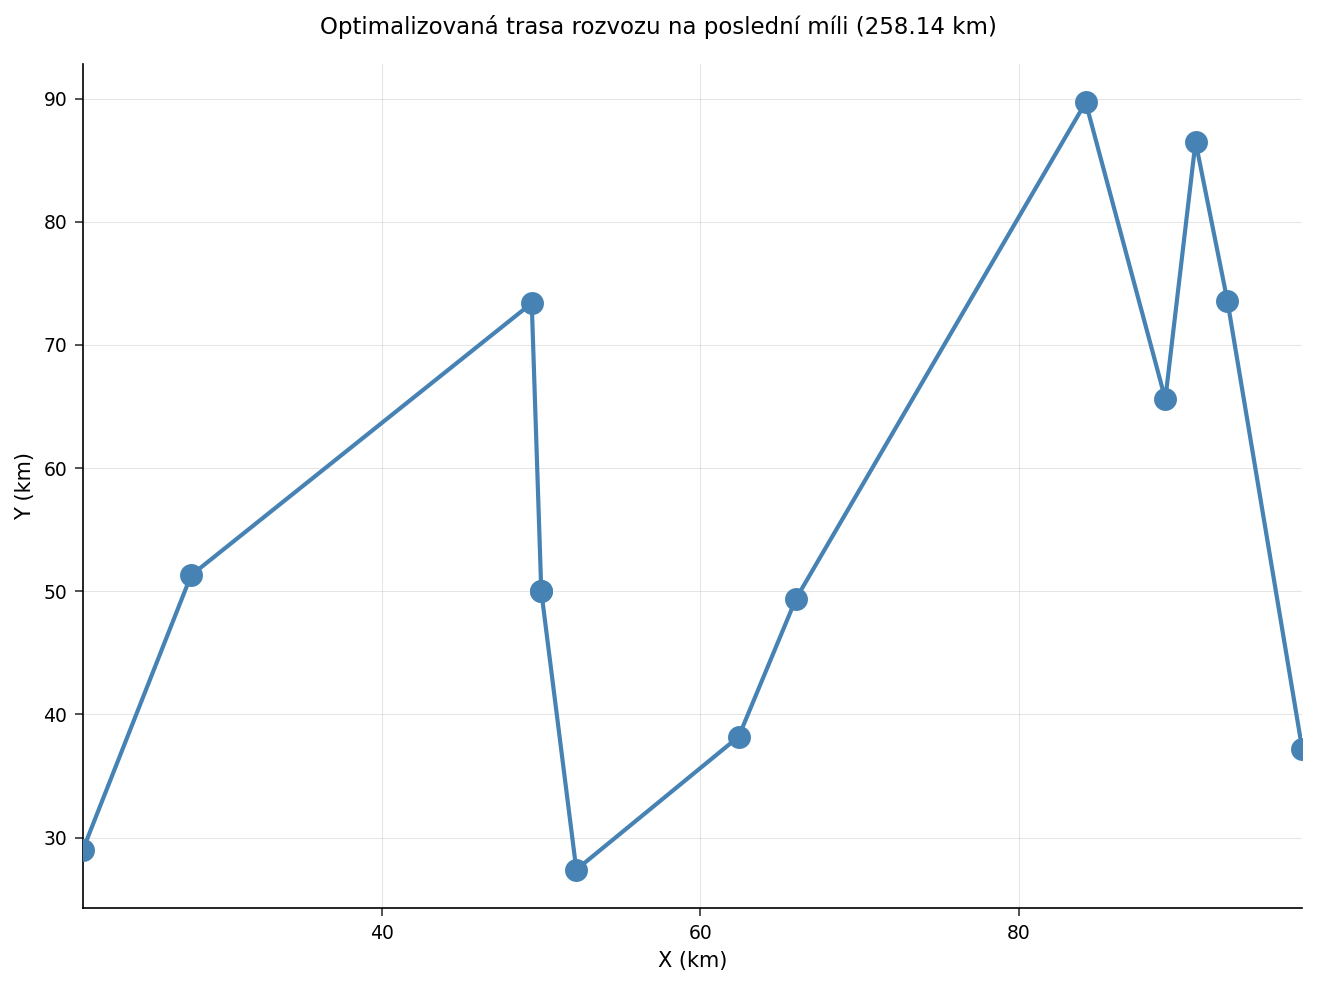

In [5]:
PROCEDURA SGPLOT data=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS ŠTÍTEK='X (km)' grid;
    YAXIS ŠTÍTEK='Y (km)' grid;
    NÁZEV "Optimalizovaná trasa rozvozu na poslední míli (&total_km km)";
SPUSTIT;


## Interpretace výsledků

- **Trasa.** Tabulky `route` a `manifest` uvádějí uzavřenou trasu, kterou
  síťový TSP řešič OPTMODEL vytvořil nad úplným grafem 12 zastávek, se začátkem
  i koncem v depu. `Celková vzdálenost` je *naměřená*: jde o součet
  euklidovských vzdáleností jednotlivých úseků (`leg_km`), takže odráží
  skutečnou geometrii sítě, nikoli odhadovanou hodnotu.
- **Proč síťový řešič.** Při 11 zákaznických zastávkách existuje
  `11! / 2 = 19 958 400` různých uzavřených tras, takže dispečer potřebuje
  algoritmus, nikoli výčet. `SOLVE WITH NETWORK / TSP` sestaví trasu přímo
  z ohodnocené množiny hran, aniž by analytik musel prohledávání ručně
  naprogramovat.
- **Od pořadí k manifestu.** Řešič vrací *pořadí* návštěv; DATA krok jej
  přemění na provozní výstup — pojmenované zastávky, vzdálenosti jednotlivých
  úseků, průběžný odometr a jednořádkový manifest, kterým se řidič může řídit.
- **Provozní rozšíření.** Stejnou kostru OPTMODEL lze rozšířit na
  propracovanější plánování tras: přidat omezení kapacity nebo časových oken
  jako další síťové volby, ohodnotit hrany dobou jízdy místo přímé vzdálenosti,
  nebo rozdělit zastávky mezi více vozidel a řešit TSP pro každé z nich zvlášť.
